<a href="https://colab.research.google.com/github/harshitasharma19-ui/-AI-Study-Bot/blob/main/face_detection!pip_install_facenet_pytorch_opencv_python_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U torch torchvision torchaudio


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


PyTorch version: 2.11.0+cpu
GPU available: False
Running on CPU


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


PyTorch version: 2.13.0+cu130
CUDA available: False
Running on CPU


In [2]:
!pip install facenet-pytorch opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 85.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 19.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [3]:
!pip install facenet-pytorch --no-deps


  Using cached facenet_pytorch-2.6.0-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.6 MB/s eta 0:00:00


In [4]:
import facenet_pytorch

print("facenet-pytorch installed successfully!")

facenet-pytorch installed successfully!


In [5]:
import torch
from facenet_pytorch import MTCNN
import cv2
import matplotlib.pyplot as plt

# Use CPU because GPU is not available
device = torch.device('cpu')

# Create the MTCNN face detector
mtcnn = MTCNN(
    keep_all=True,
    device=device
)

print("Face detector created successfully!")
print("Device:", device)

Face detector created successfully!
Device: cpu


In [6]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-08-24 185529.png to Screenshot 2026-08-24 185529.png


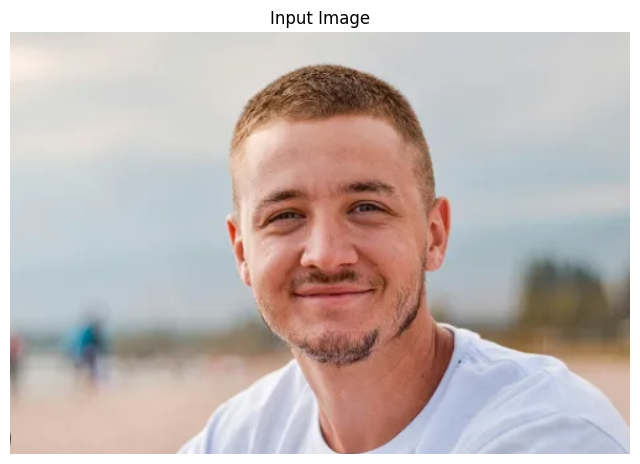

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

# Get the uploaded image filename
image_name = list(uploaded.keys())[0]

# Open the image
image = Image.open(image_name).convert("RGB")

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [8]:
# Detect faces in the image
boxes, probabilities = mtcnn.detect(image)

print("Detected face boxes:")
print(boxes)

print("\nDetection probabilities:")
print(probabilities)

Detected face boxes:
[[215.39682006835938 74.7275390625 396.4129943847656 308.3417053222656]]

Detection probabilities:
[0.9999529123306274]


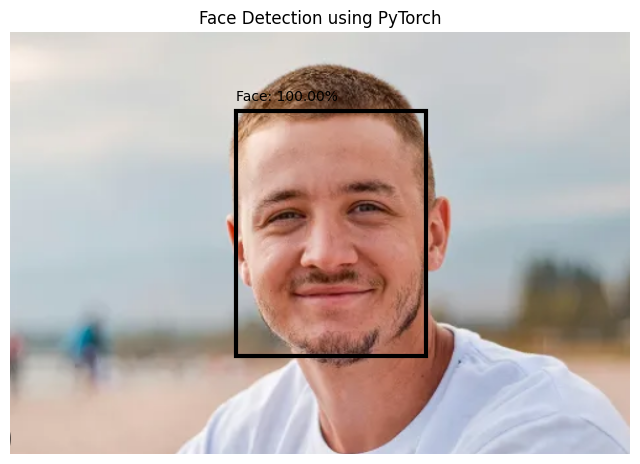

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Display the image
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image)

# Check if any face was detected
if boxes is not None:
    for box, probability in zip(boxes, probabilities):

        # Get coordinates
        x1, y1, x2, y2 = box

        # Draw bounding box
        width = x2 - x1
        height = y2 - y1

        rectangle = Rectangle(
            (x1, y1),
            width,
            height,
            fill=False,
            linewidth=3
        )

        ax.add_patch(rectangle)

        # Display confidence
        ax.text(
            x1,
            y1 - 10,
            f"Face: {probability:.2%}",
            fontsize=10
        )

else:
    print("No face detected.")

ax.axis("off")
plt.title("Face Detection using PyTorch")
plt.show()

In [10]:
keep_all=True

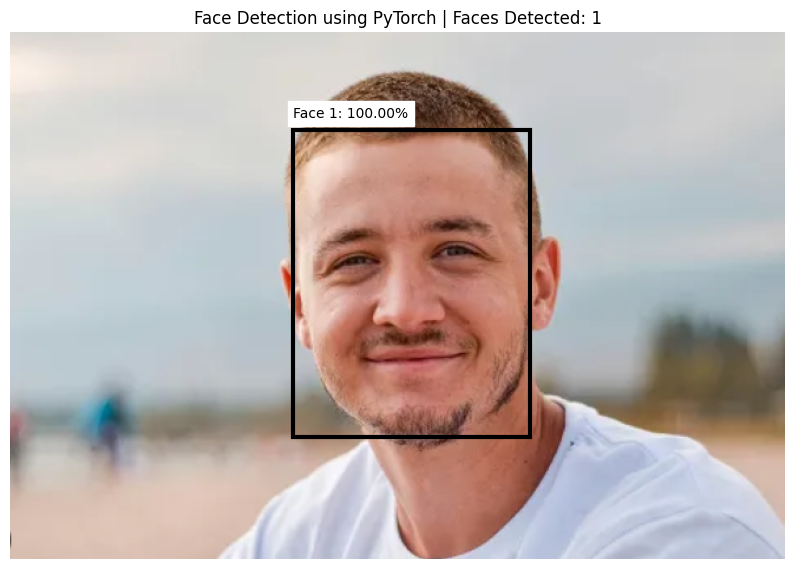

Total faces detected: 1


In [11]:
# Detect all faces
boxes, probabilities = mtcnn.detect(image)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image)

# Count detected faces
face_count = 0

if boxes is not None:
    for box, probability in zip(boxes, probabilities):

        # Ignore very low-confidence detections
        if probability > 0.90:

            x1, y1, x2, y2 = box

            width = x2 - x1
            height = y2 - y1

            # Draw bounding box
            rectangle = Rectangle(
                (x1, y1),
                width,
                height,
                fill=False,
                linewidth=3
            )

            ax.add_patch(rectangle)

            # Add confidence
            ax.text(
                x1,
                max(y1 - 10, 10),
                f"Face {face_count + 1}: {probability:.2%}",
                fontsize=10,
                backgroundcolor="white"
            )

            face_count += 1

# Display total number of faces
ax.set_title(f"Face Detection using PyTorch | Faces Detected: {face_count}")
ax.axis("off")
plt.show()

print("Total faces detected:", face_count)

In [12]:
# Create a copy of the original image
result_image = image.copy()

# Convert PIL image to OpenCV format
result_image_cv = cv2.cvtColor(
    __import__("numpy").array(result_image),
    cv2.COLOR_RGB2BGR
)

# Draw bounding boxes
if boxes is not None:
    for box, probability in zip(boxes, probabilities):

        if probability > 0.90:

            x1, y1, x2, y2 = map(int, box)

            # Draw rectangle
            cv2.rectangle(
                result_image_cv,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                3
            )

            # Add confidence
            label = f"Face: {probability:.2%}"

            cv2.putText(
                result_image_cv,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

# Save the result
output_path = "face_detection_result.jpg"
cv2.imwrite(output_path, result_image_cv)

print("Result saved as:", output_path)

Result saved as: face_detection_result.jpg


In [16]:
from google.colab import files

print("Upload another image:")
uploaded_test = files.upload()

Upload another image:


Saving Screenshot 2026-08-24 190126.png to Screenshot 2026-08-24 190126.png


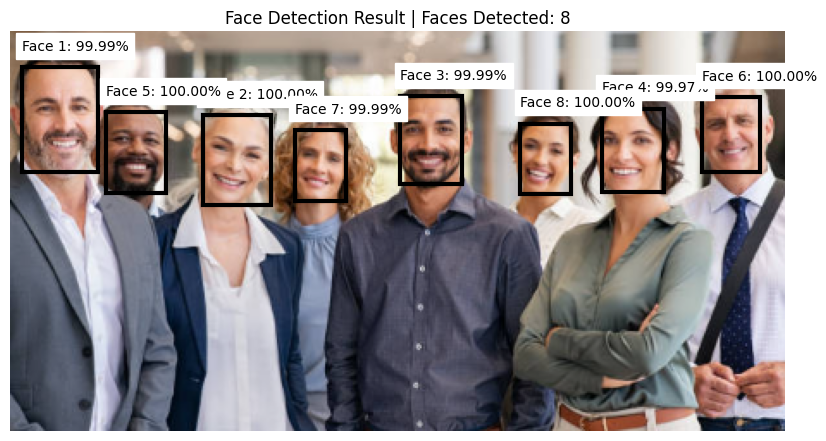

Total faces detected: 8


In [17]:
from PIL import Image
import matplotlib.pyplot as plt

# Get uploaded filename
test_image_name = list(uploaded_test.keys())[0]

# Open image
test_image = Image.open(test_image_name).convert("RGB")

# Detect faces
test_boxes, test_probabilities = mtcnn.detect(test_image)

# Display image
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(test_image)

face_count = 0

if test_boxes is not None:
    for box, probability in zip(test_boxes, test_probabilities):

        if probability > 0.90:

            x1, y1, x2, y2 = box

            rectangle = Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=3
            )

            ax.add_patch(rectangle)

            ax.text(
                x1,
                max(y1 - 10, 10),
                f"Face {face_count + 1}: {probability:.2%}",
                fontsize=10,
                backgroundcolor="white"
            )

            face_count += 1

else:
    print("No faces detected.")

ax.set_title(f"Face Detection Result | Faces Detected: {face_count}")
ax.axis("off")
plt.show()

print("Total faces detected:", face_count)

In [18]:
print("========== FACE DETECTION SUMMARY ==========")
print("Model: MTCNN")
print("Framework: PyTorch")
print("Device:", device)
print("Faces detected:", face_count)

if test_probabilities is not None:
    valid_probabilities = [
        p for p in test_probabilities if p > 0.90
    ]

    if valid_probabilities:
        print(
            "Average confidence:",
            f"{sum(valid_probabilities) / len(valid_probabilities):.2%}"
        )
else:
    print("Average confidence: N/A")

========== FACE DETECTION SUMMARY ==========
Model: MTCNN
Framework: PyTorch
Device: cpu
Faces detected: 8
Average confidence: 99.99%


In [19]:
print("========== MODEL INFORMATION ==========")

print("Model: MTCNN")
print("Framework: PyTorch")
print("Device:", device)
print("Detect Multiple Faces: Yes")
print("Confidence Threshold: 90%")

print("\nMTCNN Model:")
print(mtcnn)

========== MODEL INFORMATION ==========
Model: MTCNN
Framework: PyTorch
Device: cpu
Detect Multiple Faces: Yes
Confidence Threshold: 90%

MTCNN Model:
MTCNN(
  (pnet): PNet(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=10)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=16)
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (prelu3): PReLU(num_parameters=32)
    (conv4_1): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1))
    (softmax4_1): Softmax(dim=1)
    (conv4_2): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
  )
  (rnet): RNet(
    (conv1): Conv2d(3, 28, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=28)
    (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(28, 48, kernel_size=(3, 3), stride=(1, 1))
  

In [20]:
total_parameters = sum(
    p.numel() for p in mtcnn.parameters()
    if p.requires_grad
)

print("Trainable parameters:", total_parameters)

Trainable parameters: 495850


In [21]:
print("========================================")
print("       FACE DETECTION USING PYTORCH")
print("========================================")
print("Framework          : PyTorch")
print("Model              : MTCNN")
print("Device             :", device)
print("Multiple Faces     : Supported")
print("Confidence         : 90% minimum")
print("Faces Detected     :", face_count)
print("========================================")
print("Experiment completed successfully!")

       FACE DETECTION USING PYTORCH
Framework          : PyTorch
Model              : MTCNN
Device             : cpu
Multiple Faces     : Supported
Confidence         : 90% minimum
Faces Detected     : 8
Experiment completed successfully!
